naive: 500 replications done
b1: 500 replications done
b2: 500 replications done
=== upgrade-minus-none default-rate gap: 95% intervals ===
         mean    p2.5     p50   p97.5  includes_zero
dgm                                                 
naive  0.0272  0.0194  0.0274  0.0336          False
b1     0.0033 -0.0027  0.0034  0.0085           True
b2    -0.0034 -0.0094 -0.0034  0.0023           True

=== grade_diff odds ratio (controlling for pd_system): 95% intervals ===
  (OR < 1 with negative=upgrade coding => upgrades raise default odds)
         mean    p2.5     p50   p97.5
dgm                                  
naive  0.9794  0.9246  0.9784  1.0449
b1     0.9988  0.9360  0.9986  1.0627
b2     0.9983  0.9321  0.9967  1.0662

Saved: ../results/tables/04c_replication_summary.csv


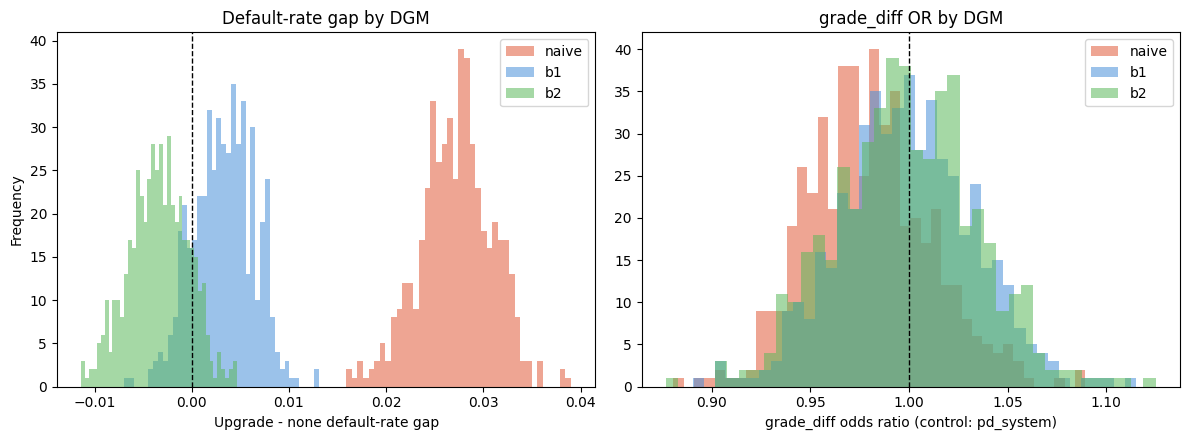

Figure saved: 04c_effect_distributions.png


In [1]:
# NB04c_override_simulation_replications.ipynb

# %% [markdown]
# # NB04c – Repeated Simulations and Distributional Inference
# **Purpose:** Quantify the uncertainty of the upgrade-risk effect under each
# DGM by repeating the simulation over many random seeds. Replaces the single
# point estimate with a full sampling distribution and percentile confidence
# intervals, directly addressing the reviewer request for repeated simulations.
#
# **Key question:** Under b1 (risk-neutral upgrades), does the upgrade-vs-none
# default-rate gap include zero in its 95% interval? If so, the residual naive
# effect is statistically indistinguishable from a mechanical artifact.
#
# **Metrics collected per replication, per DGM:**
#   - upgrade_minus_none : dr_upgrade - dr_none
#   - or_grade_diff      : odds ratio of grade_diff in a logistic regression
#                          controlling for pd_system (see note below)
#
# **Note on the OR control:** grade_diff enters a logistic regression together
# with pd_system so that the reported OR is the association *after* accounting
# for system risk. This is the same specification the paper reports, evaluated
# per replication.
#
# **Input:**  `data/processed/graded_data.parquet`  (+ engine from NB04b)
# **Output:**
#   - `results/tables/04c_replication_summary.csv`
#   - `results/figures/04c_effect_distributions.png`

# %%
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore")

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

graded = pd.read_parquet(PROC_DIR + "graded_data.parquet")

GRADE_LABELS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
GRADE_ORDER  = {g: i for i, g in enumerate(GRADE_LABELS)}
INV_GRADE    = {v: k for k, v in GRADE_ORDER.items()}
GRADE_UPGRADE_PROB = {
    "AAA": 0.10, "AA": 0.15, "A": 0.20, "BBB": 0.35,
    "BB": 0.50, "B": 0.70, "CCC": 0.80,
}

PD_COL = "pd_system"

# %% [markdown]
# ## 1. Re-import the simulation engine
# Identical to NB04b. Kept inline so this notebook runs standalone.

# %%
def _upgrade_prob_naive(df):
    return df["system_grade"].map(GRADE_UPGRADE_PROB).values

def _upgrade_prob_from_driver(df, driver_col, p_low=0.10, p_high=0.80):
    x = df[driver_col].astype(float)
    r = x.rank(pct=True, na_option="keep").values
    r = np.where(np.isnan(r), 0.5, r)
    return p_low + (p_high - p_low) * r

def simulate_override(df, dgm="naive", driver_col=None,
                      override_rate=0.35, seed=None, notch1_share=0.70):
    rng = np.random.default_rng(seed)
    df  = df.copy()
    n   = len(df)
    if dgm == "naive":
        upgrade_prob = _upgrade_prob_naive(df)
    else:
        upgrade_prob = _upgrade_prob_from_driver(df, driver_col)
    override_mask = rng.random(n) < override_rate
    upgrade_flag  = rng.random(n) < upgrade_prob
    notch         = np.where(rng.random(n) < notch1_share, 1, 2)
    delta = np.where(upgrade_flag, -notch, notch)
    new_ordinal = df["grade_ordinal"].values.copy().astype(int)
    new_ordinal[override_mask] = (
        new_ordinal[override_mask] + delta[override_mask]).clip(0, 6)
    applied_delta = new_ordinal - df["grade_ordinal"].values
    direction = np.full(n, "none", dtype=object)
    direction[(override_mask) & (applied_delta < 0)] = "upgrade"
    direction[(override_mask) & (applied_delta > 0)] = "downgrade"
    df["override_flag"]      = override_mask.astype(int)
    df["grade_diff"]         = applied_delta
    df["override_direction"] = direction
    return df

# %% [markdown]
# ## 2. One replication -> two metrics

# %%
def one_replication(df, dgm, driver_col, seed):
    sim = simulate_override(df, dgm=dgm, driver_col=driver_col,
                            override_rate=0.35, seed=seed)
    # metric 1: upgrade - none default-rate gap
    g = sim.groupby("override_direction")["default"].mean()
    gap = g.get("upgrade", np.nan) - g.get("none", np.nan)

    # metric 2: OR of grade_diff controlling for pd_system
    X = sm.add_constant(sim[["grade_diff", PD_COL]].astype(float))
    y = sim["default"].astype(int)
    try:
        res = sm.Logit(y, X).fit(disp=0)
        or_gd = np.exp(res.params["grade_diff"])
    except Exception:
        or_gd = np.nan
    return gap, or_gd

# %% [markdown]
# ## 3. Run replications
# 500 seeds per DGM. Reduce N_REP if runtime is a concern; 200 is adequate.

# %%
N_REP = 500
DGM_CONFIG = {
    "naive": (None,),
    "b1"   : ("Attr43",),
    "b2"   : ("Attr29",),
}
DGM_DRIVER = {"naive": None, "b1": "Attr43", "b2": "Attr29"}

records = []
for name, driver in DGM_DRIVER.items():
    for k in range(N_REP):
        gap, or_gd = one_replication(graded, name, driver, seed=1000 + k)
        records.append({"dgm": name, "seed": 1000 + k,
                        "gap": gap, "or_grade_diff": or_gd})
    print(f"{name}: {N_REP} replications done")

rep = pd.DataFrame(records)

# %% [markdown]
# ## 4. Percentile confidence intervals

# %%
def ci_summary(s):
    return pd.Series({
        "mean"  : s.mean(),
        "p2.5"  : s.quantile(0.025),
        "p50"   : s.quantile(0.50),
        "p97.5" : s.quantile(0.975),
    })

gap_ci = rep.groupby("dgm")["gap"].apply(ci_summary).unstack().round(4)
or_ci  = rep.groupby("dgm")["or_grade_diff"].apply(ci_summary).unstack().round(4)

# Does the 95% interval of the gap include zero?
gap_ci["includes_zero"] = (gap_ci["p2.5"] <= 0) & (gap_ci["p97.5"] >= 0)

print("=== upgrade-minus-none default-rate gap: 95% intervals ===")
print(gap_ci.reindex(["naive", "b1", "b2"]).to_string())
print("\n=== grade_diff odds ratio (controlling for pd_system): 95% intervals ===")
print("  (OR < 1 with negative=upgrade coding => upgrades raise default odds)")
print(or_ci.reindex(["naive", "b1", "b2"]).to_string())

summary = gap_ci.join(or_ci, lsuffix="_gap", rsuffix="_or")
summary.to_csv(TABLE_DIR + "04c_replication_summary.csv")
print(f"\nSaved: {TABLE_DIR}04c_replication_summary.csv")

# %% [markdown]
# ## 5. Effect distributions

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"naive": "#E05C3A", "b1": "#4A90D9", "b2": "#5CB85C"}

for name in ["naive", "b1", "b2"]:
    sub = rep[rep["dgm"] == name]
    axes[0].hist(sub["gap"], bins=40, alpha=0.55,
                 color=colors[name], label=name)
    axes[1].hist(sub["or_grade_diff"], bins=40, alpha=0.55,
                 color=colors[name], label=name)

axes[0].axvline(0, color="black", lw=1, ls="--")
axes[0].set_xlabel("Upgrade - none default-rate gap")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Default-rate gap by DGM")
axes[0].legend()

axes[1].axvline(1, color="black", lw=1, ls="--")
axes[1].set_xlabel("grade_diff odds ratio (control: pd_system)")
axes[1].set_title("grade_diff OR by DGM")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR + "04c_effect_distributions.png", bbox_inches="tight")
plt.show()
print("Figure saved: 04c_effect_distributions.png")